# Q12.
```{admonition}
:class: note
This problem is a continuation of the previous exercise. In a toy example with $p = 100$, show that one can approximate the multiple linear regression coefficient estimates by repeatedly performing simple linear regression in a backfitting procedure. How many backfitting iterations are required in order to obtain a "good" approximation to the multiple regression coefficient estimates? Create a plot to justify your answer.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng(1728)
n,p = 150,100

X = np.column_stack([np.ones(shape=(n,1)),rng.normal(size=(n,p))])
B = rng.choice([-1,1],size=p+1)*rng.integers(low=1,high=10,size=p+1)
E = rng.normal(size=n)
Y = X@B+E
true_ols = np.linalg.lstsq(X,Y)[0]

In [4]:
iterations = 100
error = {}
init_B = np.zeros(shape=101)
for i in range(iterations):
    for j in range(1,X.shape[1]):
        used_coefs = np.hstack([init_B[1:j],init_B[j+1:]])
        used_X = np.hstack([X[:,1:j],X[:,j+1:]])
        out = Y-(used_X@used_coefs)
        lr = np.polyfit(X[:,j],out,1)
        init_B[0] = lr[1]
        init_B[j] = lr[0]
    iter_error = init_B - true_ols
    error[i] = (iter_error.min(),iter_error.max(),iter_error.std(),iter_error.mean())

In [5]:
iterations = 100
error = {}
init_B = np.zeros(shape=101)
for i in range(iterations):
    for j in range(1,p+1):
        resid = Y-(X@init_B) + init_B[j]*X[:,j]+ init_B[0]
        Xj = np.column_stack([np.ones(n),X[:,j]])
        bs, *_ = np.linalg.lstsq(Xj,resid)
        init_B[j] = bs[1]
        init_B[0] = bs[0]
    iter_error = init_B - true_ols
    error[i] = (iter_error.min(),iter_error.max(),iter_error.std(),iter_error.mean())

In [6]:
iterations = 1000
error = {}
init_B = np.zeros(shape=101)
for i in range(iterations):
    for j in range(1,p+1):
        resid = Y-(X@init_B) + init_B[j]*X[:,j]+ init_B[0] #Output takes form Y-b1*X1-...-bn*Xn = b0+bj*Xj where bj*Xj is missing from left side; subtract entire fit and readd the terms to be missing to cancel out
        Xj_mean = np.mean(X[:,j])
        resid_mean = np.mean(resid)
        init_B[j] = np.sum((resid-resid_mean)*(X[:,j]-Xj_mean))/np.linalg.norm(X[:,j]-Xj_mean)**2 #closed form solution to slope
        init_B[0] = resid_mean-init_B[j]*Xj_mean #closed form solution to intercept
    iter_error = init_B - true_ols
    error[i] = (iter_error.min(),iter_error.max(),iter_error)

In [7]:
tolerance = 1e-5
for i in range(len(error)):
    if error[i][1]-error[i][0] < tolerance:
        print(f'After {i+1} iterations the range of estimates is less than {tolerance}.')
        break
    if i == len(error)-1:
        print(f'More iterations needed to achieve range less than {tolerance}.')

After 153 iterations the range of estimates is less than 1e-05.


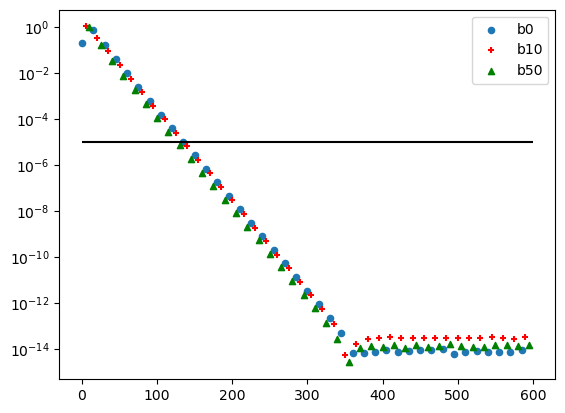

In [8]:
plt.scatter(np.arange(0,600,15),[np.abs(error[15*i][2][0]) for i in range(40)],label='b0',s=20)
plt.scatter(np.arange(5,600,15),[np.abs(error[15*i+5][2][10]) for i in range(40)],label='b10',color='r',s=20,marker='+')
plt.scatter(np.arange(10,600,15),[np.abs(error[15*i+10][2][50]) for i in range(40)],label='b50',color='g',s=20,marker='^')
plt.hlines(tolerance,0,600,'k')
plt.yscale('log')
plt.legend()
plt.show()